In [2]:
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
os.chdir("/content")
print(os.getcwd())


/content


In [4]:
from pathlib import Path
import shutil
import json

import pandas as pd
from IPython.display import display

DRIVE_ROOT = Path("/content/drive/MyDrive")
PIPELINE_ROOT = DRIVE_ROOT / "task_driven_video_pipeline"
KAGGLE_V1_ROOT = PIPELINE_ROOT / "kaggle_v1"
AUDIT_ROOT = KAGGLE_V1_ROOT / "audit"

RUN_TAG = "subject_class_balanced_20k"

MANIFEST_WITH_SPLIT_CSV = AUDIT_ROOT / f"manifest_with_split_{RUN_TAG}.csv"
SPLIT_CONFIG_JSON = AUDIT_ROOT / f"split_config_{RUN_TAG}.json"

TRAIN_CLEAN_ROOT = KAGGLE_V1_ROOT / f"train_clean_{RUN_TAG}"
VAL_CLEAN_ROOT = KAGGLE_V1_ROOT / f"val_clean_{RUN_TAG}"
TEST_CLEAN_ROOT = KAGGLE_V1_ROOT / f"test_clean_{RUN_TAG}"

MATERIALIZED_MANIFEST_CSV = AUDIT_ROOT / f"materialized_split_manifest_{RUN_TAG}.csv"
MATERIALIZED_COUNTS_CSV = AUDIT_ROOT / f"materialized_split_counts_{RUN_TAG}.csv"
MATERIALIZED_SUBJECT_COUNTS_CSV = AUDIT_ROOT / f"materialized_split_subject_counts_{RUN_TAG}.csv"

assert MANIFEST_WITH_SPLIT_CSV.exists(), f"Missing split manifest: {MANIFEST_WITH_SPLIT_CSV}"
assert SPLIT_CONFIG_JSON.exists(), f"Missing split config: {SPLIT_CONFIG_JSON}"

print("RUN_TAG:", RUN_TAG)
print("MANIFEST_WITH_SPLIT_CSV:", MANIFEST_WITH_SPLIT_CSV)
print("SPLIT_CONFIG_JSON:", SPLIT_CONFIG_JSON)
print("TRAIN_CLEAN_ROOT:", TRAIN_CLEAN_ROOT)
print("VAL_CLEAN_ROOT:", VAL_CLEAN_ROOT)
print("TEST_CLEAN_ROOT:", TEST_CLEAN_ROOT)


RUN_TAG: subject_class_balanced_20k
MANIFEST_WITH_SPLIT_CSV: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/audit/manifest_with_split_subject_class_balanced_20k.csv
SPLIT_CONFIG_JSON: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/audit/split_config_subject_class_balanced_20k.json
TRAIN_CLEAN_ROOT: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/train_clean_subject_class_balanced_20k
VAL_CLEAN_ROOT: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/val_clean_subject_class_balanced_20k
TEST_CLEAN_ROOT: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/test_clean_subject_class_balanced_20k


In [5]:
manifest_df = pd.read_csv(MANIFEST_WITH_SPLIT_CSV)

with open(SPLIT_CONFIG_JSON, "r", encoding="utf-8") as f:
    split_config = json.load(f)

print("Loaded rows:", len(manifest_df))
print("Split config keys:", sorted(split_config.keys()))

display(manifest_df.head())


Loaded rows: 20000
Split config keys: ['both_class_subjects', 'closed_only_subjects', 'exclude_unknown_subjects', 'final_test_subjects', 'final_train_subjects', 'final_val_subjects', 'include_one_class_only_in_train', 'min_per_class_for_eval', 'open_only_subjects', 'raw_clean_root', 'recommended_test_subjects', 'recommended_val_subjects', 'test_subject_count', 'val_subject_count']


,path,class_name,file_name,subject_id,width,height,mode,split
0,/content/drive/MyDrive/task_driven_video_pipel...,closed,s0001_00001_0_0_0_0_0_01.png,s0001,86,86,L,test
1,/content/drive/MyDrive/task_driven_video_pipel...,closed,s0001_00002_0_0_0_0_0_01.png,s0001,84,84,L,test
2,/content/drive/MyDrive/task_driven_video_pipel...,closed,s0001_00003_0_0_0_0_0_01.png,s0001,81,81,L,test
3,/content/drive/MyDrive/task_driven_video_pipel...,closed,s0001_00004_0_0_0_0_0_01.png,s0001,78,78,L,test
4,/content/drive/MyDrive/task_driven_video_pipel...,closed,s0001_00005_0_0_0_0_0_01.png,s0001,81,81,L,test


In [6]:
usable_df = manifest_df[manifest_df["split"].isin(["train", "val", "test"])].copy()

print("Usable rows:", len(usable_df))

display(
    usable_df["split"]
    .value_counts()
    .rename_axis("split")
    .reset_index(name="count")
    .sort_values("split")
)

display(
    usable_df.groupby(["split", "class_name"])
    .size()
    .reset_index(name="count")
    .sort_values(["split", "class_name"])
)


Usable rows: 20000


,split,count
0,test,17288
2,train,766
1,val,1946


,split,class_name,count
0,test,closed,8644
1,test,open,8644
2,train,closed,383
3,train,open,383
4,val,closed,973
5,val,open,973


In [7]:
train_subjects = sorted(usable_df.loc[usable_df["split"] == "train", "subject_id"].unique().tolist())
val_subjects = sorted(usable_df.loc[usable_df["split"] == "val", "subject_id"].unique().tolist())
test_subjects = sorted(usable_df.loc[usable_df["split"] == "test", "subject_id"].unique().tolist())

print("Train subjects:", len(train_subjects), train_subjects)
print("Val subjects:", len(val_subjects), val_subjects)
print("Test subjects:", len(test_subjects), test_subjects)

assert set(train_subjects).isdisjoint(val_subjects)
assert set(train_subjects).isdisjoint(test_subjects)
assert set(val_subjects).isdisjoint(test_subjects)

print("Subject split is disjoint.")


Train subjects: 7 ['s0002', 's0003', 's0005', 's0007', 's0009', 's0010', 's0020']
Val subjects: 4 ['s0011', 's0013', 's0016', 's0017']
Test subjects: 5 ['s0001', 's0012', 's0014', 's0015', 's0019']
Subject split is disjoint.


In [8]:
for root in [TRAIN_CLEAN_ROOT, VAL_CLEAN_ROOT, TEST_CLEAN_ROOT]:
    if root.exists():
        shutil.rmtree(root)
    (root / "open").mkdir(parents=True, exist_ok=True)
    (root / "closed").mkdir(parents=True, exist_ok=True)

print("Created output roots.")
print(TRAIN_CLEAN_ROOT)
print(VAL_CLEAN_ROOT)
print(TEST_CLEAN_ROOT)


Created output roots.
/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/train_clean_subject_class_balanced_20k
/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/val_clean_subject_class_balanced_20k
/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/test_clean_subject_class_balanced_20k


In [9]:
SPLIT_TO_ROOT = {
    "train": TRAIN_CLEAN_ROOT,
    "val": VAL_CLEAN_ROOT,
    "test": TEST_CLEAN_ROOT,
}

def safe_destination(dst_dir: Path, preferred_name: str, subject_id: str, class_name: str) -> Path:
    candidate = dst_dir / preferred_name
    if not candidate.exists():
        return candidate

    stem = Path(preferred_name).stem
    suffix = Path(preferred_name).suffix

    alt_name = f"{subject_id}__{class_name}__{preferred_name}"
    candidate = dst_dir / alt_name
    if not candidate.exists():
        return candidate

    counter = 1
    while True:
        alt_name = f"{subject_id}__{class_name}__{stem}__dup{counter}{suffix}"
        candidate = dst_dir / alt_name
        if not candidate.exists():
            return candidate
        counter += 1


In [11]:
materialized_records = []

rows = usable_df.to_dict("records")
total_rows = len(rows)

for i, row in enumerate(rows, 1):
    if i == 1 or i % 1000 == 0:
        print(f"Copying {i}/{total_rows}")

    src_path = Path(row["path"])
    split = row["split"]
    class_name = row["class_name"]
    subject_id = row["subject_id"]
    file_name = row["file_name"]

    assert split in SPLIT_TO_ROOT, f"Unexpected split: {split}"
    assert class_name in {"open", "closed"}, f"Unexpected class: {class_name}"
    assert src_path.exists(), f"Missing source file: {src_path}"

    dst_dir = SPLIT_TO_ROOT[split] / class_name
    dst_path = safe_destination(dst_dir, file_name, subject_id, class_name)

    shutil.copy2(src_path, dst_path)

    materialized_records.append({
        "split": split,
        "class_name": class_name,
        "subject_id": subject_id,
        "source_path": str(src_path),
        "dest_path": str(dst_path),
        "dest_file_name": dst_path.name,
        "width": row["width"],
        "height": row["height"],
        "mode": row["mode"],
    })

materialized_df = pd.DataFrame(materialized_records)
materialized_df.to_csv(MATERIALIZED_MANIFEST_CSV, index=False)

print("Saved materialized manifest to:", MATERIALIZED_MANIFEST_CSV)
print("Materialized rows:", len(materialized_df))


Copying 1/20000
Copying 1000/20000
Copying 2000/20000
Copying 3000/20000
Copying 4000/20000
Copying 5000/20000
Copying 6000/20000
Copying 7000/20000
Copying 8000/20000
Copying 9000/20000
Copying 10000/20000
Copying 11000/20000
Copying 12000/20000
Copying 13000/20000
Copying 14000/20000
Copying 15000/20000
Copying 16000/20000
Copying 17000/20000
Copying 18000/20000
Copying 19000/20000
Copying 20000/20000
Saved materialized manifest to: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/audit/materialized_split_manifest_subject_class_balanced_20k.csv
Materialized rows: 20000


In [12]:
materialized_counts = (
    materialized_df
    .groupby(["split", "class_name"])
    .size()
    .reset_index(name="count")
    .sort_values(["split", "class_name"])
)

materialized_counts.to_csv(MATERIALIZED_COUNTS_CSV, index=False)

display(materialized_counts)
print("Saved materialized counts to:", MATERIALIZED_COUNTS_CSV)


,split,class_name,count
0,test,closed,8644
1,test,open,8644
2,train,closed,383
3,train,open,383
4,val,closed,973
5,val,open,973


Saved materialized counts to: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/audit/materialized_split_counts_subject_class_balanced_20k.csv


In [13]:
materialized_subject_counts = (
    materialized_df
    .groupby(["split", "subject_id", "class_name"])
    .size()
    .reset_index(name="count")
    .sort_values(["split", "subject_id", "class_name"])
)

materialized_subject_counts.to_csv(MATERIALIZED_SUBJECT_COUNTS_CSV, index=False)

display(materialized_subject_counts.head(30))
print("Saved materialized subject counts to:", MATERIALIZED_SUBJECT_COUNTS_CSV)


,split,subject_id,class_name,count
0,test,s0001,closed,1185
1,test,s0001,open,1185
2,test,s0012,closed,2371
3,test,s0012,open,2371
4,test,s0014,closed,2370
5,test,s0014,open,2370
6,test,s0015,closed,348
7,test,s0015,open,348
8,test,s0019,closed,2370
9,test,s0019,open,2370


Saved materialized subject counts to: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/audit/materialized_split_subject_counts_subject_class_balanced_20k.csv


In [14]:
print("Physical file counts:")

for root in [TRAIN_CLEAN_ROOT, VAL_CLEAN_ROOT, TEST_CLEAN_ROOT]:
    print("\n", root)
    for class_name in ["open", "closed"]:
        count = len([p for p in (root / class_name).iterdir() if p.is_file()])
        print(class_name, count)


Physical file counts:

 /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/train_clean_subject_class_balanced_20k
open 383
closed 383

 /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/val_clean_subject_class_balanced_20k
open 973
closed 973

 /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/test_clean_subject_class_balanced_20k
open 8644
closed 8644


In [15]:
print("Verifying subject disjointness after materialization...")

train_subj = set(materialized_df.loc[materialized_df["split"] == "train", "subject_id"].unique().tolist())
val_subj = set(materialized_df.loc[materialized_df["split"] == "val", "subject_id"].unique().tolist())
test_subj = set(materialized_df.loc[materialized_df["split"] == "test", "subject_id"].unique().tolist())

assert train_subj.isdisjoint(val_subj)
assert train_subj.isdisjoint(test_subj)
assert val_subj.isdisjoint(test_subj)

print("Train subjects:", len(train_subj), sorted(train_subj))
print("Val subjects:", len(val_subj), sorted(val_subj))
print("Test subjects:", len(test_subj), sorted(test_subj))
print("Subject disjointness verified.")


Verifying subject disjointness after materialization...
Train subjects: 7 ['s0002', 's0003', 's0005', 's0007', 's0009', 's0010', 's0020']
Val subjects: 4 ['s0011', 's0013', 's0016', 's0017']
Test subjects: 5 ['s0001', 's0012', 's0014', 's0015', 's0019']
Subject disjointness verified.


In [16]:
!find "{TRAIN_CLEAN_ROOT}/open" -type f | wc -l
!find "{TRAIN_CLEAN_ROOT}/closed" -type f | wc -l

!find "{VAL_CLEAN_ROOT}/open" -type f | wc -l
!find "{VAL_CLEAN_ROOT}/closed" -type f | wc -l

!find "{TEST_CLEAN_ROOT}/open" -type f | wc -l
!find "{TEST_CLEAN_ROOT}/closed" -type f | wc -l


383
383
973
973
8644
8644


In [17]:
!find "{TRAIN_CLEAN_ROOT}/open" -type f | sed -n '1,5p'
!find "{VAL_CLEAN_ROOT}/open" -type f | sed -n '1,5p'
!find "{TEST_CLEAN_ROOT}/open" -type f | sed -n '1,5p'


/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/train_clean_subject_class_balanced_20k/open/s0002_01008_0_0_1_0_0_01.png
/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/train_clean_subject_class_balanced_20k/open/s0002_01009_0_0_1_0_0_01.png
/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/train_clean_subject_class_balanced_20k/open/s0002_01010_0_0_1_0_0_01.png
/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/train_clean_subject_class_balanced_20k/open/s0002_01011_0_0_1_0_0_01.png
/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/train_clean_subject_class_balanced_20k/open/s0002_01012_0_0_1_0_0_01.png
/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/val_clean_subject_class_balanced_20k/open/s0011_01509_0_0_1_0_0_01.png
/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/val_clean_subject_class_balanced_20k/open/s0011_01510_0_0_1_0_0_01.png
/content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/val_clean_sub

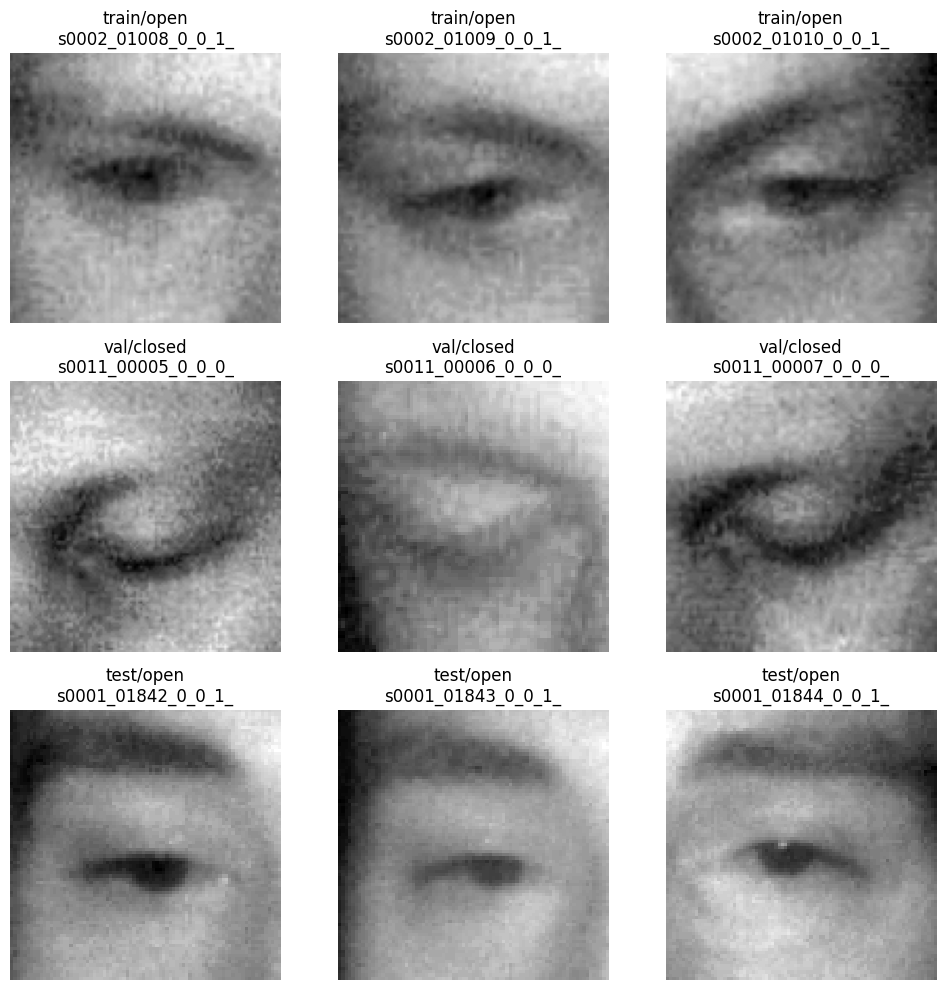

In [18]:
from PIL import Image
import matplotlib.pyplot as plt

def preview_split(split_root: Path, class_name: str, n: int = 3):
    return sorted((split_root / class_name).glob("*"))[:n]

train_open_samples = preview_split(TRAIN_CLEAN_ROOT, "open", 3)
val_closed_samples = preview_split(VAL_CLEAN_ROOT, "closed", 3)
test_open_samples = preview_split(TEST_CLEAN_ROOT, "open", 3)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))

sample_groups = [
    ("train/open", train_open_samples),
    ("val/closed", val_closed_samples),
    ("test/open", test_open_samples),
]

for row_idx, (title, samples) in enumerate(sample_groups):
    for col_idx in range(3):
        ax = axes[row_idx, col_idx]
        if col_idx < len(samples):
            img = Image.open(samples[col_idx])
            ax.imshow(img, cmap="gray")
            ax.set_title(f"{title}\n{samples[col_idx].name[:18]}")
        ax.axis("off")

plt.tight_layout()
plt.show()


In [19]:
print("Updated Phase 2 complete.")
print("TRAIN_CLEAN_ROOT:", TRAIN_CLEAN_ROOT)
print("VAL_CLEAN_ROOT:", VAL_CLEAN_ROOT)
print("TEST_CLEAN_ROOT:", TEST_CLEAN_ROOT)
print("MATERIALIZED_MANIFEST_CSV:", MATERIALIZED_MANIFEST_CSV)
print("MATERIALIZED_COUNTS_CSV:", MATERIALIZED_COUNTS_CSV)
print("MATERIALIZED_SUBJECT_COUNTS_CSV:", MATERIALIZED_SUBJECT_COUNTS_CSV)


Updated Phase 2 complete.
TRAIN_CLEAN_ROOT: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/train_clean_subject_class_balanced_20k
VAL_CLEAN_ROOT: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/val_clean_subject_class_balanced_20k
TEST_CLEAN_ROOT: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/test_clean_subject_class_balanced_20k
MATERIALIZED_MANIFEST_CSV: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/audit/materialized_split_manifest_subject_class_balanced_20k.csv
MATERIALIZED_COUNTS_CSV: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/audit/materialized_split_counts_subject_class_balanced_20k.csv
MATERIALIZED_SUBJECT_COUNTS_CSV: /content/drive/MyDrive/task_driven_video_pipeline/kaggle_v1/audit/materialized_split_subject_counts_subject_class_balanced_20k.csv
